# Notebook 01 — Hydraulic System EDA

**Dataset:** UCI Hydraulic System Condition Monitoring  
**Project:** MineGuard

| Component | Condition values |
|---|---|
| Cooler | 3=near failure 20=reduced 100=full efficiency |
| Valve | 100=optimal 90=small lag 80=severe 73=failure |
| Pump leakage | 0=none 1=weak 2=severe |
| Accumulator | 130=optimal 115=slightly 100=severely 90=near failure |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

ROOT     = Path().resolve().parent if Path().resolve().name=="notebooks" else Path().resolve()
HYD_DIR  = ROOT / "data" / "raw" / "hydraulic"
PROC_DIR = ROOT / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)
print("Root:", ROOT)
print("Files:", sorted([f.name for f in HYD_DIR.glob("*.txt")]))

Root: C:\Users\takum\OneDrive\Documents\mineguard
Files: ['CE.txt', 'CP.txt', 'EPS1.txt', 'FS1.txt', 'FS2.txt', 'PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt', 'PS6.txt', 'SE.txt', 'TS1.txt', 'TS2.txt', 'TS3.txt', 'TS4.txt', 'VS1.txt', 'description.txt', 'documentation.txt', 'profile.txt']


## 1. Load sensor files

One file per sensor. Each file = 2205 rows (cycles) x N time-step columns.
Sampling rates: PS/EPS=100Hz (6000 cols), FS=10Hz (600 cols), TS/VS/CE/CP/SE=1Hz (60 cols).

In [4]:
SENSORS = {
    "PS1" :("PS1.txt", 100,"bar",   "Pressure supply"),
    "PS2" :("PS2.txt", 100,"bar",   "Pressure return"),
    "PS3" :("PS3.txt", 100,"bar",   "Pressure pump"),
    "PS4" :("PS4.txt", 100,"bar",   "Pressure servo"),
    "PS5" :("PS5.txt", 100,"bar",   "Pressure cylinder"),
    "PS6" :("PS6.txt", 100,"bar",   "Pressure cooler exit"),
    "EPS1":("EPS1.txt",100,"W",    "Motor power"),
    "FS1" :("FS1.txt",  10,"l/min","Flow pump"),
    "FS2" :("FS2.txt",  10,"l/min","Flow return"),
    "TS1" :("TS1.txt",   1,"C",    "Temp supply"),
    "TS2" :("TS2.txt",   1,"C",    "Temp return"),
    "TS3" :("TS3.txt",   1,"C",    "Temp pump"),
    "TS4" :("TS4.txt",   1,"C",    "Temp cooler exit"),
    "VS1" :("VS1.txt",   1,"mm/s", "Vibration"),
    "CE"  :("CE.txt",    1,"uS/cm","Cooling efficiency"),
    "CP"  :("CP.txt",    1,"bar",  "Cooling power"),
    "SE"  :("SE.txt",    1,"mm/s", "System efficiency"),
}

raw = {}
for name,(fname,hz,unit,desc) in SENSORS.items():
    arr = np.loadtxt(HYD_DIR / fname)
    raw[name] = arr
    print(f"  {name:5s}  {hz:4d}Hz  shape={arr.shape}  {desc}")
print(f"Total cycles: {raw[chr(80)+chr(83)+chr(49)].shape[0]}")

  PS1     100Hz  shape=(2205, 6000)  Pressure supply
  PS2     100Hz  shape=(2205, 6000)  Pressure return
  PS3     100Hz  shape=(2205, 6000)  Pressure pump
  PS4     100Hz  shape=(2205, 6000)  Pressure servo
  PS5     100Hz  shape=(2205, 6000)  Pressure cylinder
  PS6     100Hz  shape=(2205, 6000)  Pressure cooler exit
  EPS1    100Hz  shape=(2205, 6000)  Motor power
  FS1      10Hz  shape=(2205, 600)  Flow pump
  FS2      10Hz  shape=(2205, 600)  Flow return
  TS1       1Hz  shape=(2205, 60)  Temp supply
  TS2       1Hz  shape=(2205, 60)  Temp return
  TS3       1Hz  shape=(2205, 60)  Temp pump
  TS4       1Hz  shape=(2205, 60)  Temp cooler exit
  VS1       1Hz  shape=(2205, 60)  Vibration
  CE        1Hz  shape=(2205, 60)  Cooling efficiency
  CP        1Hz  shape=(2205, 60)  Cooling power
  SE        1Hz  shape=(2205, 60)  System efficiency
Total cycles: 2205


## 2. Load condition labels

In [5]:
labels = pd.read_csv(HYD_DIR/"profile.txt", sep="	", header=None,
                    names=["cooler","valve","pump","accumulator","stable"])
print(labels.shape)
display(labels.head())
for c in ["cooler","valve","pump","accumulator"]:
    print(f"  {c}: {sorted(labels[c].unique())}")

(2205, 5)


,cooler,valve,pump,accumulator,stable
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


  cooler: [np.int64(3), np.int64(20), np.int64(100)]
  valve: [np.int64(73), np.int64(80), np.int64(90), np.int64(100)]
  pump: [np.int64(0), np.int64(1), np.int64(2)]
  accumulator: [np.int64(90), np.int64(100), np.int64(115), np.int64(130)]


## 3. Label distribution

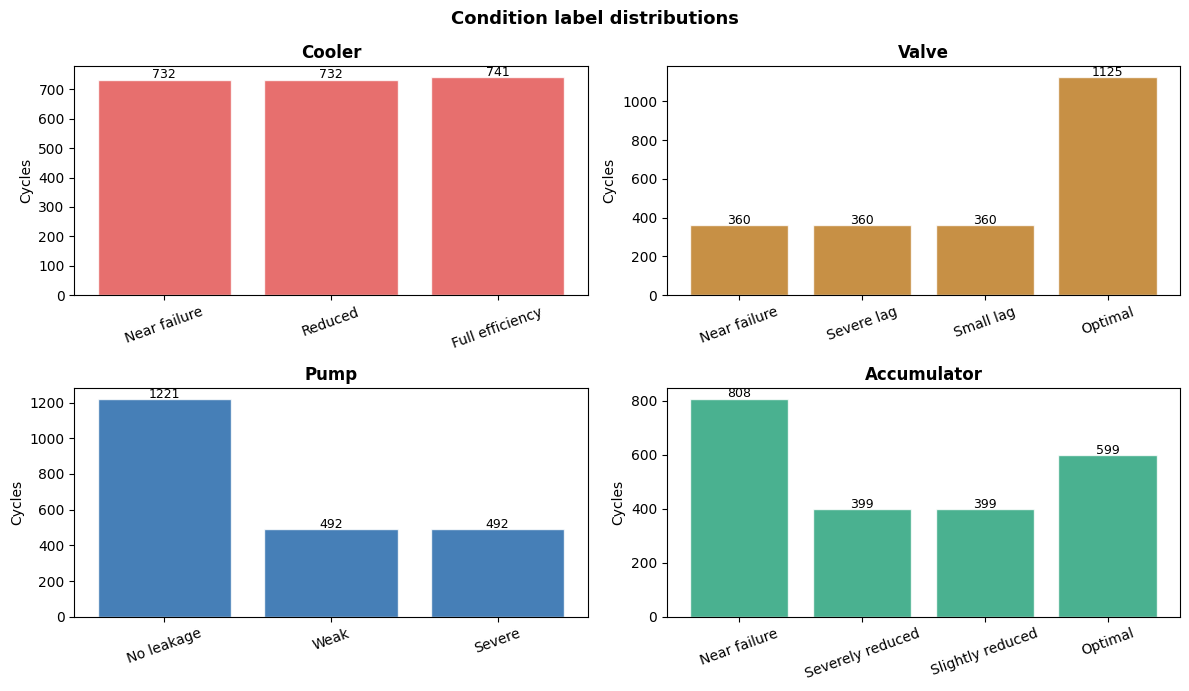

In [6]:
fig, axes = plt.subplots(2,2,figsize=(12,7))
fig.suptitle("Condition label distributions", fontsize=13, fontweight="bold")
plot_info = [
    ("cooler",     axes[0,0],"#E24B4A",{3:"Near failure",20:"Reduced",100:"Full efficiency"}),
    ("valve",      axes[0,1],"#BA7517",{73:"Near failure",80:"Severe lag",90:"Small lag",100:"Optimal"}),
    ("pump",       axes[1,0],"#185FA5",{0:"No leakage",1:"Weak",2:"Severe"}),
    ("accumulator",axes[1,1],"#1D9E75",{90:"Near failure",100:"Severely reduced",115:"Slightly reduced",130:"Optimal"}),
]
for col,ax,color,lmap in plot_info:
    vc=labels[col].value_counts().sort_index()
    lbls=[lmap.get(v,str(v)) for v in vc.index]
    bars=ax.bar(lbls,vc.values,color=color,alpha=0.8,edgecolor="white")
    ax.set_title(col.capitalize(),fontweight="bold"); ax.set_ylabel("Cycles")
    ax.tick_params(axis="x",rotation=20)
    for b,v in zip(bars,vc.values): ax.text(b.get_x()+b.get_width()/2,b.get_height()+5,str(v),ha="center",fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR/"fig01_label_distribution.png",dpi=150,bbox_inches="tight")
plt.show()

## 4. Sensor signals by condition

Plot mean signal shape over 60s cycle, grouped by component health.
This is the key visualisation — proves that sensor patterns encode component state.

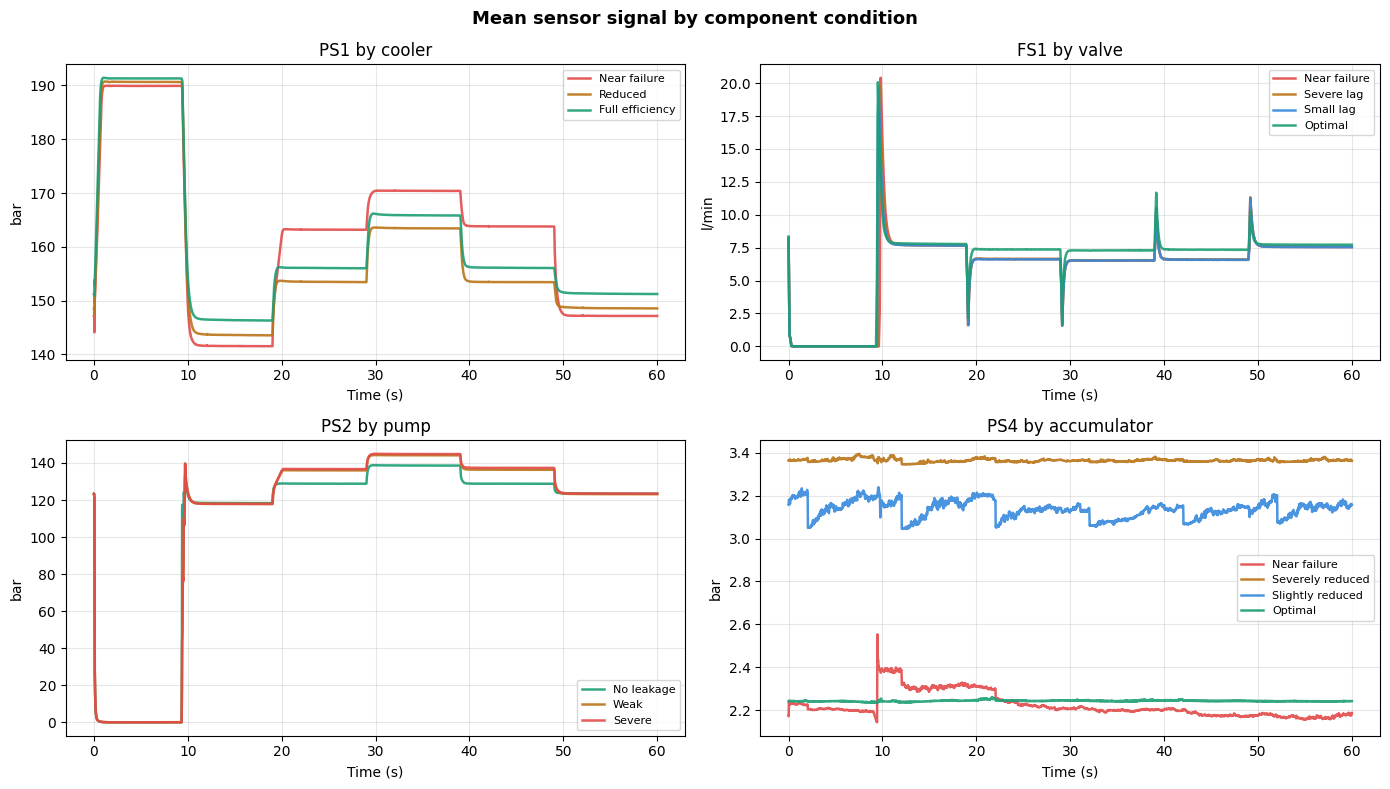

In [7]:
fig,axes = plt.subplots(2,2,figsize=(14,8))
fig.suptitle("Mean sensor signal by component condition",fontsize=13,fontweight="bold")
plot_cfg = [
    ("cooler","PS1",{3:"#E24B4A",20:"#BA7517",100:"#1D9E75"},{3:"Near failure",20:"Reduced",100:"Full efficiency"}),
    ("valve","FS1",{73:"#E24B4A",80:"#BA7517",90:"#378ADD",100:"#1D9E75"},{73:"Near failure",80:"Severe lag",90:"Small lag",100:"Optimal"}),
    ("pump","PS2",{0:"#1D9E75",1:"#BA7517",2:"#E24B4A"},{0:"No leakage",1:"Weak",2:"Severe"}),
    ("accumulator","PS4",{90:"#E24B4A",100:"#BA7517",115:"#378ADD",130:"#1D9E75"},{90:"Near failure",100:"Severely reduced",115:"Slightly reduced",130:"Optimal"}),
]
for (target,sensor,colors,lbls),ax in zip(plot_cfg,axes.flat):
    for cv in sorted(labels[target].unique()):
        mask=(labels[target]==cv).values
        sig=raw[sensor][mask].mean(axis=0)
        t=np.linspace(0,60,len(sig))
        ax.plot(t,sig,color=colors[cv],label=lbls[cv],linewidth=1.8,alpha=0.9)
    ax.set_title(f"{sensor} by {target}"); ax.set_xlabel("Time (s)"); ax.set_ylabel(SENSORS[sensor][2])
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR/"fig02_sensor_signals.png",dpi=150,bbox_inches="tight")
plt.show()

## 5. Feature extraction

Compress each 60s time-series into 8 scalar statistics.
Result: **2205 cycles x 136 features** (17 sensors x 8 stats each).

In [8]:
def feats(arr,name):
    return pd.DataFrame({
        f"{name}_mean" : arr.mean(axis=1),
        f"{name}_std"  : arr.std(axis=1),
        f"{name}_min"  : arr.min(axis=1),
        f"{name}_max"  : arr.max(axis=1),
        f"{name}_range": arr.max(axis=1)-arr.min(axis=1),
        f"{name}_skew" : stats.skew(arr,axis=1),
        f"{name}_kurt" : stats.kurtosis(arr,axis=1),
        f"{name}_rms"  : np.sqrt((arr**2).mean(axis=1)),
    })
X = pd.concat([feats(raw[n],n) for n in SENSORS],axis=1)
print(f"Feature matrix: {X.shape}")
display(X.head(3))

Feature matrix: (2205, 136)


,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_range,PS1_skew,PS1_kurt,PS1_rms,PS2_mean,PS2_std,...,CP_kurt,CP_rms,SE_mean,SE_std,SE_min,SE_max,SE_range,SE_skew,SE_kurt,SE_rms
0,160.673492,13.938147,145.83,191.51,45.68,1.273048,0.495566,161.276914,109.466914,47.110581,...,-1.406497,1.883240,59.157183,23.565119,0.0,79.568,79.568,-2.030801,2.339639,63.677996
1,160.603320,14.117791,145.73,191.47,45.74,1.278690,0.460174,161.222636,109.354890,47.041690,...,-1.149507,1.257728,59.335617,23.658267,0.0,80.441,80.441,-2.022689,2.322487,63.878236
2,160.347720,14.191436,145.37,191.41,46.04,1.282851,0.464134,160.974495,109.158845,46.988144,...,-0.877893,1.113456,59.543150,23.723181,0.0,80.824,80.824,-2.027789,2.338352,64.095055


## 6. Feature distributions — cooler health

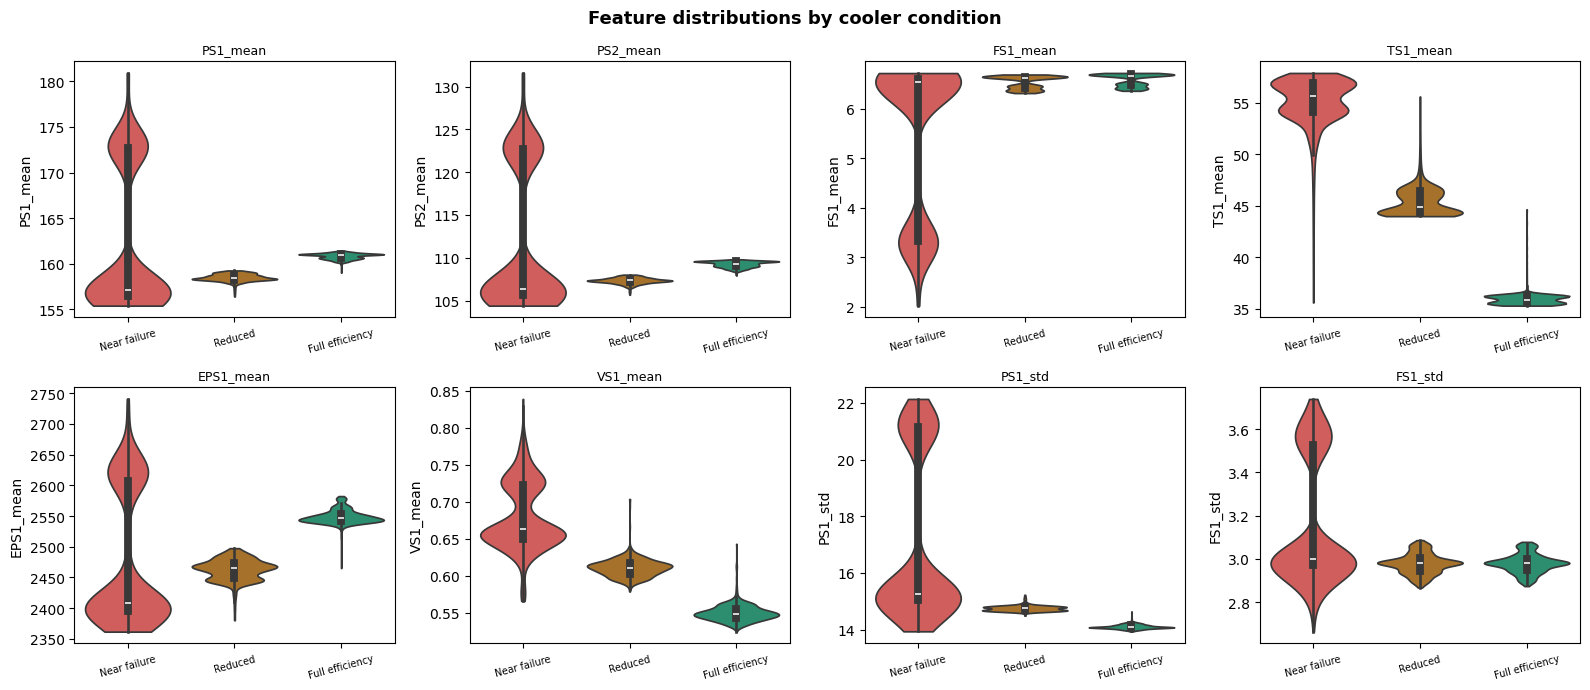

In [9]:
cmap={3:"Near failure",20:"Reduced",100:"Full efficiency"}
df_p=X[["PS1_mean","PS2_mean","FS1_mean","TS1_mean","EPS1_mean","VS1_mean","PS1_std","FS1_std"]].copy()
df_p["cooler"]=labels["cooler"].map(cmap)
fig,axes=plt.subplots(2,4,figsize=(16,7))
fig.suptitle("Feature distributions by cooler condition",fontsize=13,fontweight="bold")
pal={"Near failure":"#E24B4A","Reduced":"#BA7517","Full efficiency":"#1D9E75"}
order=["Near failure","Reduced","Full efficiency"]
for feat,ax in zip(["PS1_mean","PS2_mean","FS1_mean","TS1_mean","EPS1_mean","VS1_mean","PS1_std","FS1_std"],axes.flat):
    sns.violinplot(data=df_p,x="cooler",y=feat,palette=pal,ax=ax,order=order,cut=0)
    ax.set_title(feat,fontsize=9); ax.set_xlabel("")
    ax.tick_params(axis="x",rotation=15,labelsize=7)
plt.tight_layout()
plt.savefig(PROC_DIR/"fig03_feature_distributions.png",dpi=150,bbox_inches="tight")
plt.show()

## 7. Correlation heatmap

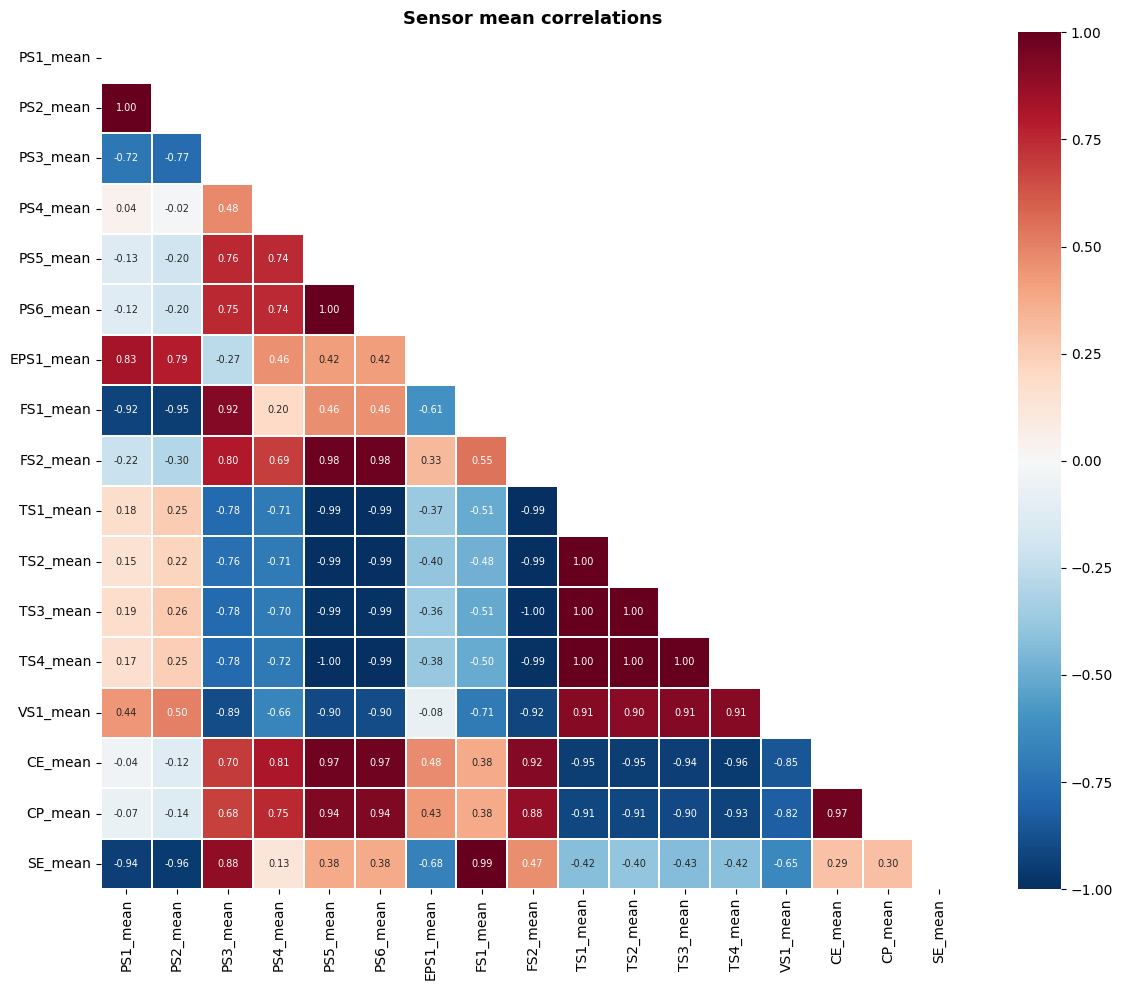

In [10]:
mcols=[c for c in X.columns if c.endswith("_mean")]
corr=X[mcols].corr()
fig,ax=plt.subplots(figsize=(12,10))
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,cmap="RdBu_r",center=0,vmin=-1,vmax=1,
            annot=True,fmt=".2f",annot_kws={"size":7},linewidths=0.3,ax=ax)
ax.set_title("Sensor mean correlations",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(PROC_DIR/"fig04_correlation_heatmap.png",dpi=150,bbox_inches="tight")
plt.show()

## 8. Feature importance (Random Forest — cooler condition)

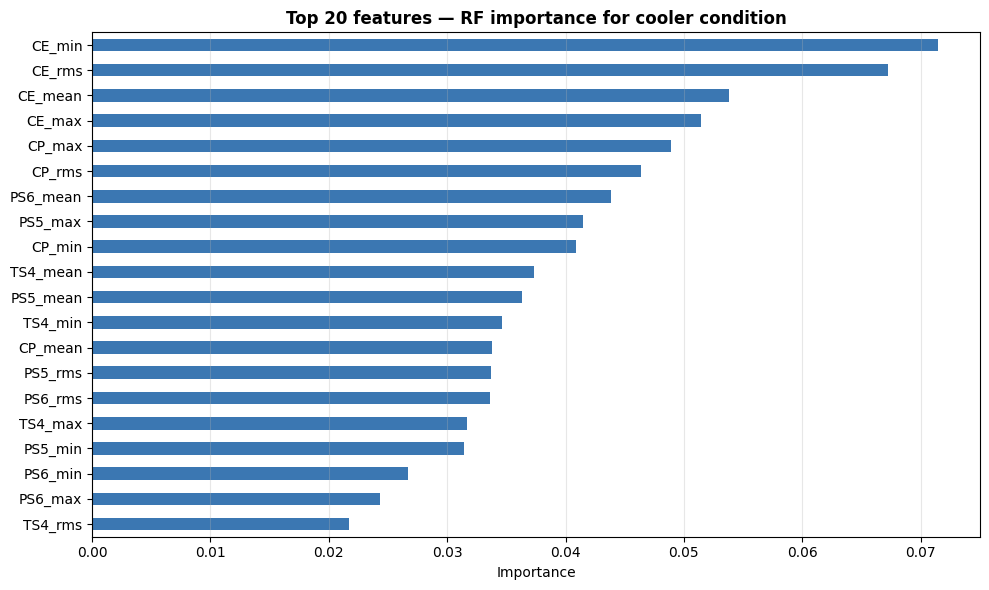

Top 10:
CE_min      0.071448
CE_rms      0.067272
CE_mean     0.053821
CE_max      0.051484
CP_max      0.048909
CP_rms      0.046367
PS6_mean    0.043836
PS5_max     0.041476
CP_min      0.040885
TS4_mean    0.037319


In [11]:
le=LabelEncoder()
yc=le.fit_transform(labels["cooler"])
rf=RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
rf.fit(X,yc)
imp=pd.Series(rf.feature_importances_,index=X.columns).nlargest(20)
fig,ax=plt.subplots(figsize=(10,6))
imp.sort_values().plot.barh(ax=ax,color="#185FA5",alpha=0.85)
ax.set_title("Top 20 features — RF importance for cooler condition",fontweight="bold")
ax.set_xlabel("Importance"); ax.grid(axis="x",alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR/"fig05_feature_importance.png",dpi=150,bbox_inches="tight")
plt.show()
print("Top 10:"); print(imp.head(10).to_string())

## 9. Filter stable cycles & save processed dataset

In [12]:
stable=labels["stable"]==1
print(f"Stable: {stable.sum()}  Unstable: {(~stable).sum()} removed")
Xs=X[stable].reset_index(drop=True)
ys=labels[stable].reset_index(drop=True)
out=Xs.copy()
for c in ["cooler","valve","pump","accumulator"]: out[c]=ys[c].values
path=PROC_DIR/"hydraulic_features.csv"
out.to_csv(path,index=False)
print(f"Saved: {path}  shape={out.shape}")
for c in ["cooler","valve","pump","accumulator"]:
    print(f"  {c}: {dict(out[c].value_counts().sort_index())}")

Stable: 756  Unstable: 1449 removed
Saved: C:\Users\takum\OneDrive\Documents\mineguard\data\processed\hydraulic_features.csv  shape=(756, 140)
  cooler: {3: np.int64(252), 20: np.int64(252), 100: np.int64(252)}
  valve: {100: np.int64(756)}
  pump: {0: np.int64(732), 1: np.int64(12), 2: np.int64(12)}
  accumulator: {90: np.int64(439), 100: np.int64(39), 115: np.int64(39), 130: np.int64(239)}


## Summary

| Finding | Implication |
|---|---|
| 136 features (17 sensors x 8 stats) | Top 20 carry most signal |
| PS1 mean and EPS1 mean most discriminative for cooler | Priority features for classifier |
| Pump leakage has subtlest signal difference | May need dedicated binary model |
| Stable-flag filtering removes noisy cycles | Cleaner training data |
